In [1]:
%load_ext autoreload
%autoreload 2

In [105]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder
from ariel_pred.metrics import score
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

Randomly selected index: 1064
Predicted s value: 0.009239837907935606


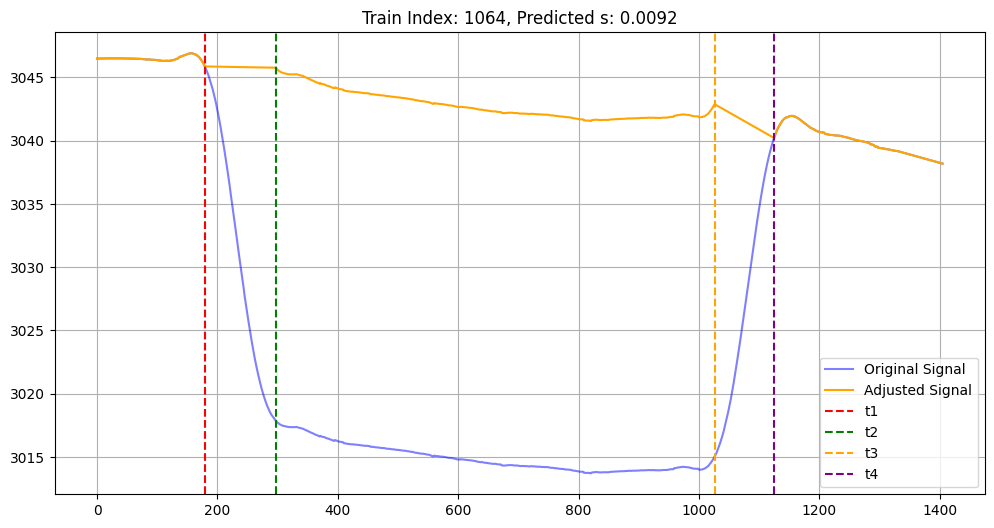

In [27]:
random_index = random.randint(0, len(train_data) - 1)
print(f"Randomly selected index: {random_index}")
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_detector = FunctionFittingBasedPhaseDetector()
signal = smoother.smooth(train_data[random_index].copy().mean(axis=1))
t1, t2, t3, t4 = transit_detector.phase_detect(
    smoother.smooth(signal)
)
s_finder = TransitMultiplicationFactorFinder(poly_degree=3, error_degree=1)
s = s_finder.predict(signal, t1, t2, t3, t4)
y = np.concatenate([signal[:t1], signal[t2:t3] * (s + 1.0), signal[t4:]])
x = np.concatenate([np.arange(t1), np.arange(t2, t3), np.arange(t4, len(signal))])

print(f"Predicted s value: {s}")
plt.figure(figsize=(12, 6))
plt.plot(signal, color="blue", alpha=0.5, label="Original Signal")
plt.plot(x, y, color="orange", label="Adjusted Signal")
plt.title(f"Train Index: {random_index}, Predicted s: {s:.4f}")
plt.axvline(t1, color="red", linestyle="--", label="t1")
plt.axvline(t2, color="green", linestyle="--", label="t2")
plt.axvline(t3, color="orange", linestyle="--", label="t3")
plt.axvline(t4, color="purple", linestyle="--", label="t4")
plt.legend()
plt.grid()
plt.show()

Randomly selected index: 438


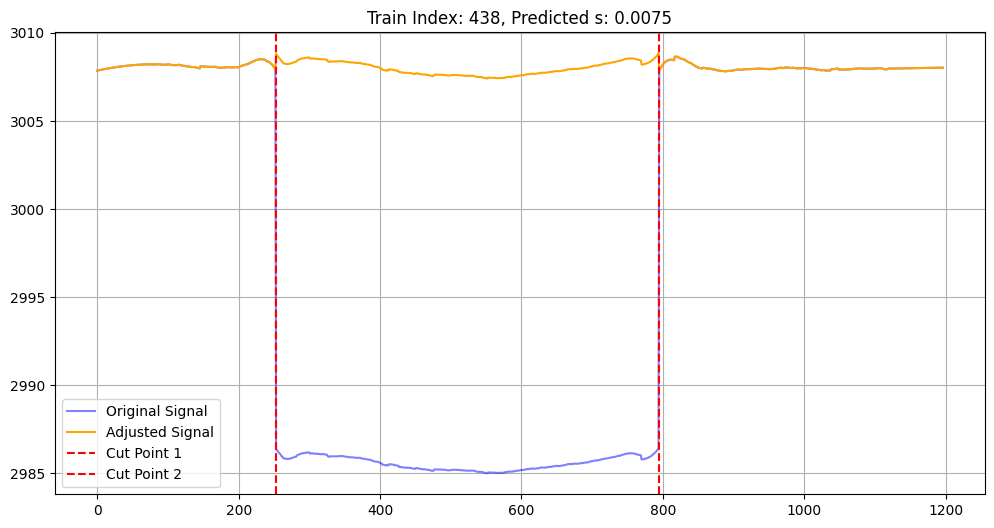

In [43]:
random_index = random.randint(0, len(train_data) - 1)
print(f"Randomly selected index: {random_index}")
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_detector = FunctionFittingBasedPhaseDetector()
signal = smoother.smooth(train_data[random_index].copy().mean(axis=1))
t1, t2, t3, t4 = transit_detector.phase_detect(
    smoother.smooth(signal)
)
s_finder = TransitMultiplicationFactorFinder(poly_degree=3, error_degree=1)
s = s_finder.predict(signal, t1, t2, t3, t4)

plt.figure(figsize=(12, 6))
plt.plot(np.concatenate([signal[:t1], signal[t2:t3], signal[t4:]]), color="blue", alpha=0.5, label="Original Signal")
plt.plot(np.concatenate([signal[:t1], signal[t2:t3] * (s+1), signal[t4:]]), color="orange", label="Adjusted Signal")
plt.title(f"Train Index: {random_index}, Predicted s: {s:.4f}")
plt.axvline(t1, color="red", linestyle="--", label="Cut Point 1")
plt.axvline(t3 - (t2-t1), color="red", linestyle="--", label="Cut Point 2")
plt.legend()
plt.grid()
plt.show()

In [ ]:
random_index = random.randint(0, len(train_data) - 1)
print(f"Randomly selected index: {random_index}")
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_detector = FunctionFittingBasedPhaseDetector()

t1, t2, t3, t4 = transit_detector.phase_detect(
    smoother.smooth(train_data[random_index].copy().mean(axis=1))
)

channels_binning = 2
ranges = np.array_split(np.arange(train_data.shape[2]), channels_binning)
s_finder = TransitMultiplicationFactorFinder(poly_degree=3, error_degree=1)

predictions = np.zeros(train_data.shape[2])

for r in ranges:
    signal = train_data[random_index].copy()
    signal = smoother.smooth(signal[:, r].mean(axis=1))
    s = s_finder.predict(signal, t1, t2, t3, t4)
    predictions[r] = s
    plt.figure(figsize=(12, 6))
    plt.plot(np.concatenate([signal[:t1], signal[t2:t3], signal[t4:]]), color="blue", alpha=0.5, label="Original Signal")
    plt.plot(np.concatenate([signal[:t1], signal[t2:t3] * (s+1), signal[t4:]]), color="orange", label="Adjusted Signal")
    plt.title(f"Train Index: {random_index}, Predicted s: {s:.4f}, Channels: {r[0]}-{r[-1]}")
    plt.axvline(t1, color="red", linestyle="--", label="Cut Point 1")
    plt.axvline(t3 - (t2-t1), color="red", linestyle="--", label="Cut Point 2")
    plt.legend()
    plt.grid()
    plt.show()

labels = train_labels[random_index]
plt.figure(figsize=(12, 6))
plt.plot(labels)
plt.plot(predictions)
plt.title(f"Train Index: {random_index}, True vs Predicted s values")
plt.xlabel("Channel")
plt.ylabel("s value")
plt.legend(["True s", "Predicted s"])
plt.grid()
plt.show()

In [ ]:
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_detector = FunctionFittingBasedPhaseDetector()

channels_binning = 1
ranges = np.array_split(np.arange(train_data.shape[2]), channels_binning)
s_finder = TransitMultiplicationFactorFinder(poly_degree=3, error_degree=1)

predictions = np.zeros((train_data.shape[0], train_data.shape[2]))

for i, data in enumerate(tqdm(train_data)):
    t1, t2, t3, t4 = transit_detector.phase_detect(
        smoother.smooth(data.copy().mean(axis=1))
    )
    for r in ranges:
        signal = data.copy()
        signal = smoother.smooth(signal[:, r].mean(axis=1))
        s = s_finder.predict(signal, t1, t2, t3, t4)
        predictions[i, r] = s

labels = train_labels.copy()
sigma = 0.0009
predictions = np.concatenate([predictions, sigma * np.ones_like(predictions)], axis=1)

labels_df = pd.DataFrame(labels).reset_index()
predictions_df = pd.DataFrame(predictions).reset_index()


gll = score(solution=labels_df, submission=predictions_df, row_id_column_name="index", naive_mean=labels.mean(), naive_sigma=labels.std())
gll

  0%|          | 0/1100 [00:00<?, ?it/s]

0.24781950670632757

In [ ]:
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_detector = FunctionFittingBasedPhaseDetector()

ranges = np.array_split(np.arange(train_data.shape[2]), channels_binning)
s_finder = TransitMultiplicationFactorFinder(poly_degree=3, error_degree=1)

predictions = np.zeros((train_data.shape[0], train_data.shape[2]))

channel_binnings = [1, 2, 4, 8]
weights = [0.4, 0.3, 0.2, 0.1]
for i, data in enumerate(tqdm(train_data)):
    t1, t2, t3, t4 = transit_detector.phase_detect(
        smoother.smooth(data.copy().mean(axis=1))
    )
    ranges_list = [np.array_split(np.arange(train_data.shape[2]), cb) for cb in channel_binnings]
    for ranges, weight in zip(ranges_list, weights):
        for r in ranges:
            signal = data.copy()
            signal = smoother.smooth(signal[:, r].mean(axis=1))
            s = s_finder.predict(signal, t1, t2, t3, t4)
            predictions[i, r] += s * weight

labels = train_labels.copy()
SIGMA = 0.0009

labels_df = pd.DataFrame(labels).reset_index()
predictions_df = pd.DataFrame(np.concatenate([predictions, SIGMA * np.ones_like(predictions)], axis=1)).reset_index()


gll = score(solution=labels_df, submission=predictions_df, row_id_column_name="index", naive_mean=labels.mean(), naive_sigma=labels.std())
gll

  0%|          | 0/1100 [00:00<?, ?it/s]

0.25319003495304515

In [ ]:
def generate_predictions(
    full_data: np.ndarray,
    channel_binnings: list[int] = [1, 2, 4, 8],
    weights: list[float] = [0.4, 0.3, 0.2, 0.1],
    sg_smoothing_window_size: int = 150,
    sg_smoothing_poly_order: int = 2,
    transit_window_size: int = 100,
    transit_width: int = 300,
    poly_degree: int = 3,
    error_degree: int = 1
) -> np.ndarray:
    
    assert len(channel_binnings) == len(weights), "Channel binnings and weights must have the same length"
    smoother = SGSmoothing(window_size=sg_smoothing_window_size, poly_order=sg_smoothing_poly_order)
    transit_detector = FunctionFittingBasedPhaseDetector(window_size=transit_window_size, width=transit_width)

    s_finder = TransitMultiplicationFactorFinder(poly_degree=poly_degree, error_degree=error_degree)

    predictions = np.zeros((full_data.shape[0], full_data.shape[2]))

    for i, data in enumerate(tqdm(full_data)):
        t1, t2, t3, t4 = transit_detector.phase_detect(
            smoother.smooth(data.copy().mean(axis=1))
        )

        ranges_list = [np.array_split(np.arange(full_data.shape[2]), cb) for cb in channel_binnings]
        for ranges, weight in zip(ranges_list, weights):
            for r in ranges:
                signal = data.copy()
                signal = smoother.smooth(signal[:, r].mean(axis=1))
                s = s_finder.predict(signal, t1, t2, t3, t4)
                predictions[i, r] += s * weight
    
    predictions = predictions * (1.0 / np.sum(weights))
    return predictions

In [143]:
labels = train_labels.copy()
channel_binnings = [283]
weights = [1.0]
predictions = generate_predictions(train_data, channel_binnings, weights)

def cost_function(params, predictions, labels):
    sigma = params[0]
    scale = params[1]
    
    if sigma <= 0:
        return 2.0
    labels_df = pd.DataFrame(labels).reset_index()
    predictions_df = pd.DataFrame(np.concatenate([scale*predictions, sigma * np.ones_like(predictions)], axis=1)).reset_index()
    gll = score(solution=labels_df, submission=predictions_df, row_id_column_name="index", naive_mean=labels.mean(), naive_sigma=labels.std())
    return -gll

initial_sigma = 0.001
result = minimize(
    cost_function, 
    x0=[initial_sigma, 1.00], 
    args=(predictions, labels), 
    method='Nelder-Mead', 
    bounds=[(1e-6, 0.2), (0.75, 1.25)]
)
result.x, -result.fun

  0%|          | 0/1100 [00:00<?, ?it/s]

Exception: Negative values in the submission

In [138]:
def calc_gll(sigma, predictions, labels):
    labels_df = pd.DataFrame(labels).reset_index()
    predictions_df = pd.DataFrame(np.concatenate([predictions, sigma * np.ones_like(predictions)], axis=1)).reset_index()
    gll = score(solution=labels_df, submission=predictions_df, row_id_column_name="index", naive_mean=labels.mean(), naive_sigma=labels.std())
    return gll

In [142]:
calc_gll(0.0012, predictions*0.93, labels)

0.3071467471338783

In [136]:
1 / 7

0.14285714285714285